# Introduction to the spin model

A protein is modeled as a 2d lattice of Ising spins $\sigma_i = \pm 1$, `W` spins wide (periodic across the width) and `L+1` layers long. Each spin carries one amino acid from an alphabet of size `q`, so a sequence has `W*(L+1)` residues.

The sequence sets the physics through a random lookup table `K`: the residue at a site sets the field $h_i$ on its spin, and each pair of residues in neighboring layers sets the coupling $J_{ij}$ between their spins. A configuration has weight $\exp\left(\sum_i h_i \sigma_i + \sum_{ij} J_{ij} \sigma_i \sigma_j\right)$ (inverse temperature fixed to 1), and the free energy $F = -\log Z$ is computed exactly with transfer matrices.

A **ligand** binds by adding a field to the binding-site spin. Ligand $k$ has binding free energy $\Delta F_k = F_k - F_\text{solvent}$ (negative means it binds), where the solvent adds zero field. Here two ligands with opposite fields, $+1$ and $-1$, compete for the same site, and the fitness is **generalist (double) binding**, $\phi = \min(-\Delta F_1, -\Delta F_2)$: a fit protein binds both.

## 1. Load packages

In [1]:
using Revise      # reload edits to src automatically
using Random, Statistics, PyPlot, LaTeXStrings
using SpinModel

[ Info: Precompiling SpinModel [4566f221-5d8e-403d-8f93-18b6f18534f5](cache misses: include_dependency fsize change (3), wrong dep version loaded (1), incompatible header (1), mismatched flags (1))
[ Info: Precompiling SpinModel [4566f221-5d8e-403d-8f93-18b6f18534f5] (cache misses: include_dependency fsize change (6), wrong dep version loaded (2), incompatible header (2), mismatched flags (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## 2. Parameters

The binding site is a single spin, the middle spin of the last layer. The solvent adds no field there; ligand 1 adds $+1$ and ligand 2 adds $-1$.

In [2]:
Random.seed!(5)  # reproducible random numbers

# Model
W = 5                  # lattice width (spins per layer)
L = 10                 # number of layers minus one
q = 5                  # amino acid alphabet size
sh = 3                 # std of random fields
sJ = 3                 # std of random couplings
Q = Settings(W, L, q)  # model size settings

# Solvent and ligands
site = [CartesianIndex(3, L + 1, 1)]  # middle spin of last layer
ℓ_solvent = [0.0]                     # solvent: zero field
ℓ_1 = [1.0]                           # ligand 1: field +1
ℓ_2 = [-1.0]                          # ligand 2: field -1
ligs = Ligands([
    Perturbation(site, ℓ_solvent),  # 1: solvent (unbound)
    Perturbation(site, ℓ_1),        # 2: ligand 1 bound
    Perturbation(site, ℓ_2),        # 3: ligand 2 bound
])

# Evolution
assay = DoubleBinding()  # ϕ = min(-ΔF₁, -ΔF₂)
ζ = 100                  # selection strength
N = 1000;                # Monte Carlo steps

## 3. Build a model from a random sequence

`rand_table` draws the lookup table `K` (fields with std `sh`, couplings with std `sJ`), and `seq2J` turns a sequence into its fields and couplings `J`. In the lattice drawing, line width is coupling strength (red positive, blue negative) and the binding layer `L+1` is on the left.

In [3]:
K = rand_table(W, L, q, sh, sJ)  # sequence → couplings lookup table
seq = randSeq(Q)                 # random sequence
J = seq2J(seq, K)                # fields and couplings, (W, L+1, 3)

println("sequence on the lattice (rows = spins, columns = layers):")
display(reshape(seq, W, L + 1))

sequence on the lattice (rows = spins, columns = layers):


5×11 Matrix{Int8}:
 1  1  2  4  3  4  2  2  4  4  3
 5  5  5  3  5  1  2  5  3  1  4
 1  3  5  1  4  1  2  4  2  3  5
 2  2  1  1  2  5  2  1  2  3  5
 3  3  4  3  4  2  4  4  2  1  5

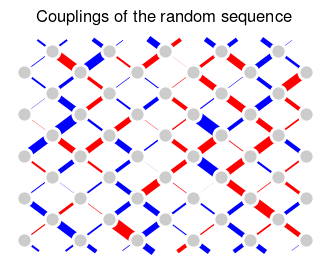

In [4]:
fig = plotCouplings(seq, K, Q; maxCouplingSize=1.5, maxSiteSize=8)
fig.axes[1].set_title("Couplings of the random sequence");

## 4. Binding fitness of the random sequence

For a single spin, $e^{h\sigma} = \cosh h + \sigma \sinh h$, so $-\Delta F_k = \log\left(\cosh h_k + m \sinh h_k\right)$ depends only on the binding-site magnetization $m = \langle \sigma \rangle$ in the solvent. A spin polarized toward $+1$ binds ligand 1 and repels ligand 2, and vice versa.

In [5]:
F = computeFreeEnergies(seq, K, Q, ligs)    # [F_solvent, F_1, F_2]
ΔF = F[2:3] .- F[1]                         # binding free energies
ϕ = computeFitness(seq, K, Q, ligs, assay)  # min(-ΔF₁, -ΔF₂)

println("ΔF₁ = ", round(ΔF[1], digits=3), ",  ΔF₂ = ", round(ΔF[2], digits=3))
println("generalist fitness ϕ = ", round(ϕ, digits=3))

ΔF₁ = 1.0,  ΔF₂ = -1.0
generalist fitness ϕ = -1.0


### 4.1 A mutation changes the fitness

Substitute the residue of the binding-site spin. Sequence position `p` sits on spin `mod1(p, W)` of layer `cld(p, W)`, so spin 3 of layer `L+1` is position `W*L + 3`.

In [6]:
pos = W * L + 3                  # binding-site residue
seq_mut = copy(seq)
seq_mut[pos] = seq[pos] % q + 1  # a different amino acid
F_mut = computeFreeEnergies(seq_mut, K, Q, ligs)
ϕ_mut = computeFitness(seq_mut, K, Q, ligs, assay)

println("mutation at position $pos: amino acid $(seq[pos]) → $(seq_mut[pos])")
println("ΔF₁: ", round(ΔF[1], digits=3), " → ", round(F_mut[2] - F_mut[1], digits=3))
println("ΔF₂: ", round(ΔF[2], digits=3), " → ", round(F_mut[3] - F_mut[1], digits=3))
println("fitness ϕ: ", round(ϕ, digits=3), " → ", round(ϕ_mut, digits=3),
        "   (Δϕ = ", round(ϕ_mut - ϕ, digits=3), ")")

mutation at position 53: amino acid 5 → 1
ΔF₁: 1.0 → -0.902
ΔF₂: -1.0 → 0.474
fitness ϕ: -1.0 → -0.474   (Δϕ = 0.526)


## 5. Monte Carlo evolution

`evolve` runs Metropolis Monte Carlo on the sequence: each step proposes a random point mutation and accepts it with probability $\min(1, e^{\zeta \Delta\phi})$. Since the two ligands pull the site spin in opposite directions, the best generalist has an unpolarized site, $m = 0$, which gives $\phi = \log\cosh 1 \approx 0.43$ (dashed line).

fitness ϕ: -1.0 → 0.422


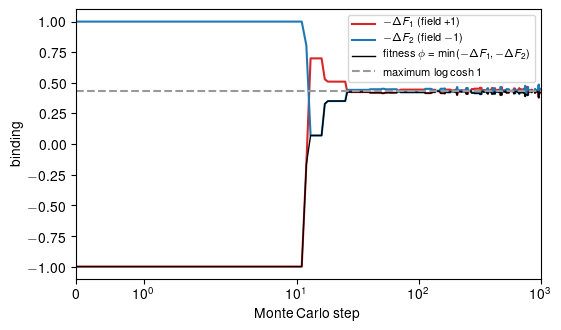

In [7]:
times, fitnesses, sequences = evolve(seq, K, Q, ligs, assay, N; ζ)
seq_evo = sequences[end]  # evolved sequence

energies = stack(s -> computeFreeEnergies(s, K, Q, ligs), sequences)  # (3, steps)
bind_1 = energies[1, :] .- energies[2, :]  # -ΔF₁
bind_2 = energies[1, :] .- energies[3, :]  # -ΔF₂

fig, ax = subplots(figsize=(6, 3.5))
ax.plot(times, bind_1, color="tab:red", lw=1.5, label=L"$-\Delta F_1$ (field $+1$)")
ax.plot(times, bind_2, color="tab:blue", lw=1.5, label=L"$-\Delta F_2$ (field $-1$)")
ax.plot(times, fitnesses, color="k", lw=1, label=L"fitness $\phi = \min(-\Delta F_1, -\Delta F_2)$")
ax.axhline(log(cosh(ℓ_1[1])), color="0.6", ls="--", label=L"maximum $\log\cosh 1$")
ax.set_xscale("symlog", linthresh=1)  # the early climb is fast
ax.set_xlim(0, N)
ax.set_xlabel("Monte Carlo step")
ax.set_ylabel("binding")
ax.legend(fontsize=8)
println("fitness ϕ: ", round(fitnesses[1], digits=3), " → ", round(fitnesses[end], digits=3))

## 6. The evolved sequence

### 6.1 Magnetization change upon ligand binding

`plotMagnetizations` draws $\langle \sigma_i \rangle$ in the solvent ($s$), bound to ligand 1 ($r$) and bound to ligand 2 ($w$), and below them the changes between states (halved so they lie in $[-1, 1]$). Dot size grows with the magnitude (red positive, blue negative); the arrow marks the binding site.

binding-site ⟨σ⟩: solvent -0.01,  ligand 1 0.76,  ligand 2 -0.77
largest change on binding outside the binding layer: 0.77 (ligand 1), 0.75 (ligand 2)


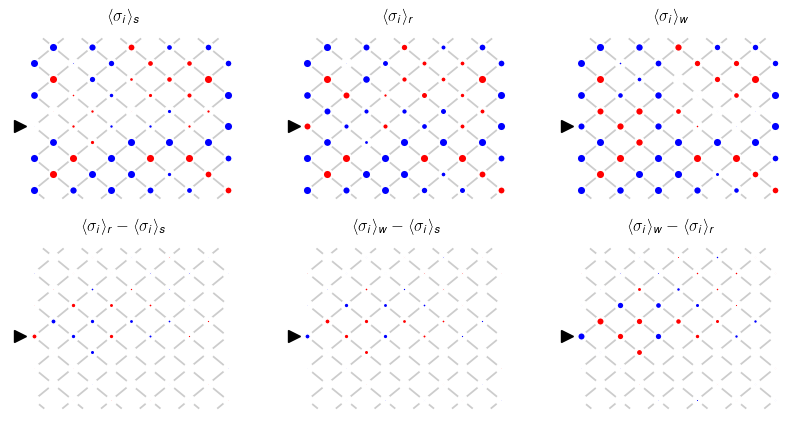

In [8]:
M = computeMagnetization(seq_evo, K, Q, ligs)  # ⟨σ_i⟩ per state, (W, L+1)

fig = plotMagnetizations(seq_evo, K, Q, ligs; size_point=1.5)
for a in fig.axes
    a.plot(-0.2, site[1][1], marker=">", color="k", markersize=8)
end

println("binding-site ⟨σ⟩: solvent ", round(M[1][site[1][1], L+1], digits=2),
        ",  ligand 1 ", round(M[2][site[1][1], L+1], digits=2),
        ",  ligand 2 ", round(M[3][site[1][1], L+1], digits=2))
println("largest change on binding outside the binding layer: ",
        round(maximum(abs, (M[2] .- M[1])[:, 1:L]), digits=2), " (ligand 1), ",
        round(maximum(abs, (M[3] .- M[1])[:, 1:L]), digits=2), " (ligand 2)")

### 6.2 Deep mutational scan

`computeBindingDMS` computes $\Delta\Delta F_k$ for every single mutant and each ligand. The top two panels show the change in binding, $\Delta(-\Delta F_k) = -\Delta\Delta F_k$ (red binds better); the bottom panel shows the change in generalist fitness $\Delta\phi$. Black dots mark the evolved (wild-type) residues, whose entries are zero. The binding site is in the rightmost layer.

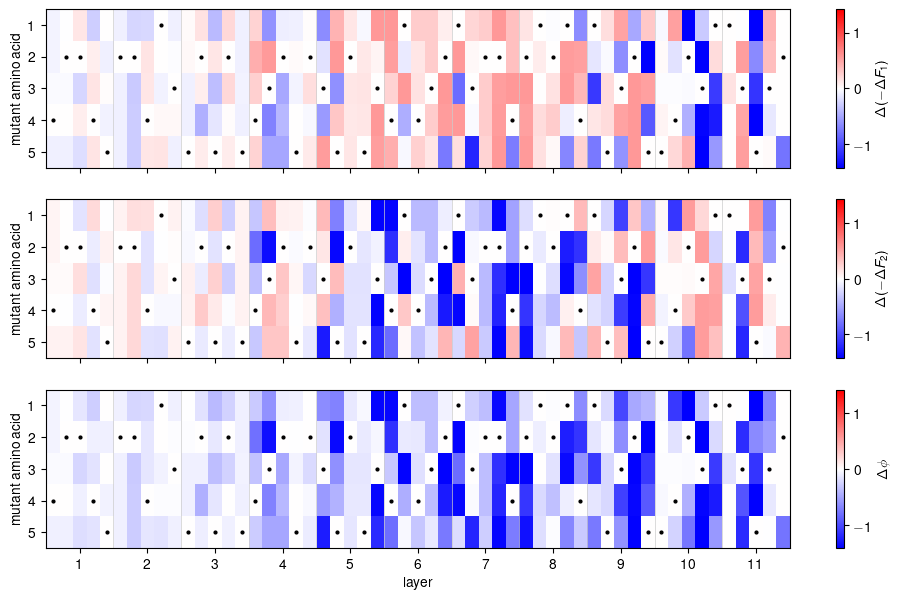

In [9]:
dms = computeBindingDMS(seq_evo, K, Q, ligs)  # ΔΔF, (q, W*(L+1), 2)

F_evo = computeFreeEnergies(seq_evo, K, Q, ligs)
ΔF_evo = F_evo[2:3] .- F_evo[1]
ϕ_evo = computeFitness(seq_evo, K, Q, ligs, assay)
Δϕ = min.(-(ΔF_evo[1] .+ dms[:, :, 1]), -(ΔF_evo[2] .+ dms[:, :, 2])) .- ϕ_evo  # fitness change

panels = [-dms[:, :, 1], -dms[:, :, 2], Δϕ]
labels = [L"\Delta(-\Delta F_1)", L"\Delta(-\Delta F_2)", L"\Delta\phi"]
fig, axs = subplots(3, 1, figsize=(12, 7), sharex=true)
for (ax, data, label) in zip(axs, panels, labels)
    c = maximum(abs, data)
    im = ax.imshow(data, cmap="bwr", vmin=-c, vmax=c, aspect="auto")
    fig.colorbar(im, ax=ax, label=label)
    ax.scatter(0:length(seq_evo)-1, seq_evo .- 1, s=4, c="k")
    for k in 1:L
        ax.axvline(W * k - 0.5, color="0.8", lw=0.5)
    end
    ax.set_yticks(0:q-1)
    ax.set_yticklabels(1:q)
    ax.set_ylabel("mutant amino acid")
end
axs[end].set_xticks(W * (0:L) .+ (W - 1) / 2)
axs[end].set_xticklabels(1:L+1)
axs[end].set_xlabel("layer");

## 7. Mutational sensitivity on the lattice

`plotMutationalSensitivity!` averages $|\Delta\Delta F_k|$ over the mutations at each site and both ligands, and draws it on the lattice (dot size). The arrow marks the binding site.

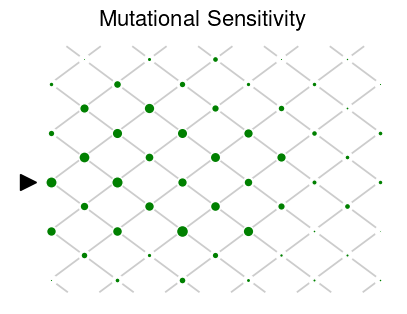

In [14]:
fig, ax = subplots(figsize=(5, 3.5))
plotMutationalSensitivity!(ax, seq_evo, K, Q, ligs; size_point=4)
ax.plot(-0.2, site[1][1], marker=">", color="k", markersize=12);